In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import NEOfaster as nf
import NEOMOD3 as nm3
import neoom as no
import S3Marray as sm
import importlib
from functools import reduce
importlib.reload(sm)

<module 'S3Marray' from '/astro/users/ds2004/digest3/S3Marray.py'>

In [13]:
s3m = sm.define_s3m()
s3m,array4D, H_center, a_center, e_center, i_center = sm.s3m_array(s3m)

['S1_00.s3m', 'S1_01.s3m', 'S1_02.s3m', 'S1_03.s3m', 'S1_04.s3m', 'S1_05.s3m', 'S1_06.s3m', 'S1_07.s3m', 'S1_08.s3m', 'S1_09.s3m', 'S1_10.s3m', 'S1_11.s3m', 'S1_12.s3m', 'S1_13.s3m']
The final df is done.


N(low-i MBAs): 6087
N(mid-i MBAs): 43572
N(high-i MBAs): 119779
Total counts low-i  : 6087.0
Total counts mid-i  : 43572.0
Total counts high-i  : 119779.0
Total counts full S3M: 13883361.0


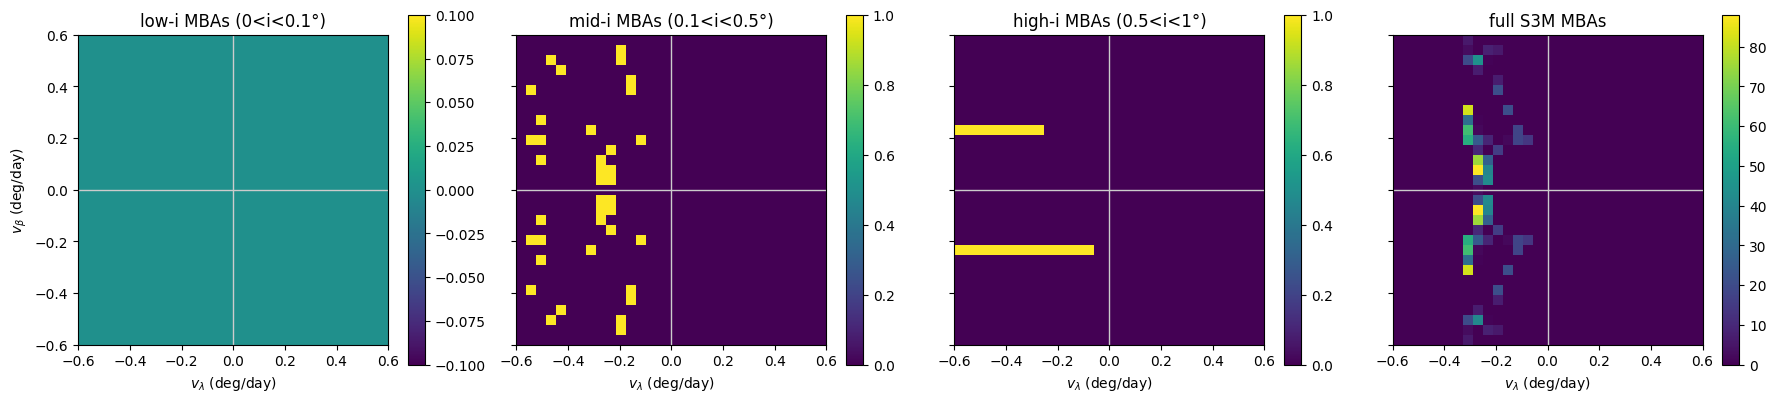

In [17]:
import numpy as np
import matplotlib.pyplot as plt


low_i_only = s3m[(s3m["i"] > 0.0) & (s3m["i"] < 0.1)].copy()
print("N(low-i MBAs):", len(low_i_only))

mid_i_only = s3m[(s3m["i"] > 0.1) & (s3m["i"] < 0.5)].copy()
print("N(mid-i MBAs):", len(mid_i_only))

high_i_only = s3m[(s3m["i"] > 0.5) & (s3m["i"] < 1.0)].copy()
print("N(high-i MBAs):", len(high_i_only))


def build_4d_hist(df, n_H=52, n_a=42, n_e=25, n_i=22):
    H_min, H_max = df["H"].min(), df["H"].max()
    a_min, a_max = df["a"].min(), df["a"].max()
    e_min, e_max = df["e"].min(), df["e"].max()
    i_min, i_max = df["i"].min(), df["i"].max()

    points = np.vstack([df["H"], df["a"], df["e"], df["i"]]).T

    edges = [
        np.linspace(H_min, H_max, n_H + 1),
        np.linspace(a_min, a_max, n_a + 1),
        np.linspace(e_min, e_max, n_e + 1),
        np.linspace(i_min, i_max, n_i + 1),
    ]

    array4D, edges_out = np.histogramdd(points, bins=edges)

    H_edges, a_edges, e_edges, i_edges = edges_out
    H_center = 0.5 * (H_edges[1:] + H_edges[:-1])
    a_center = 0.5 * (a_edges[1:] + a_edges[:-1])
    e_center = 0.5 * (e_edges[1:] + e_edges[:-1])
    i_center = 0.5 * (i_edges[1:] + i_edges[:-1])

    return array4D, H_center, a_center, e_center, i_center


array4D_low,  Hc_low,  ac_low,  ec_low,  ic_low  = build_4d_hist(low_i_only)
array4D_mid,  Hc_mid,  ac_mid,  ec_mid,  ic_mid  = build_4d_hist(mid_i_only)
array4D_high,  Hc_high,  ac_high,  ec_high,  ic_high = build_4d_hist(high_i_only)
array4D_s3m,  Hc_s3m,  ac_s3m,  ec_s3m,  ic_s3m = build_4d_hist(s3m)

print("Total counts low-i  :", array4D_low.sum())
print("Total counts mid-i  :", array4D_mid.sum())
print("Total counts high-i  :", array4D_high.sum())
print("Total counts full S3M:", array4D_s3m.sum())

def compute_k_map(array4D, H_center, a_center, e_center, i_center,
                  ra0_deg, dec0_deg, obstime_str,
                  vmin=-0.6, vmax=0.6, N_rate=31):
    vlam_vals = np.linspace(vmin, vmax, N_rate)
    vbet_vals = np.linspace(vmin, vmax, N_rate)

    K = np.zeros((len(vlam_vals), len(vbet_vals)), dtype=float)

    for i, vlam in enumerate(vlam_vals):
        for j, vbet in enumerate(vbet_vals):
            dra, ddec = no.ecliptic_rates_to_radec_rates(ra0_deg, dec0_deg,
                                                         vlam, vbet)
            w_int = no.weight_marginalized_over_d_and_ddot(
                array4D=array4D,
                H_center=H_center,
                a_center=a_center,
                e_center=e_center,
                i_center=i_center,
                ra_deg=ra0_deg,
                dec_deg=dec0_deg,
                dra_deg_per_day=dra,
                ddec_deg_per_day=ddec,
                obstime_str=obstime_str,
            )
            K[j, i] = w_int   # j = v_beta (rows), i = v_lambda (cols)

    extent = [vlam_vals[0], vlam_vals[-1], vbet_vals[0], vbet_vals[-1]]
    return K, extent, vlam_vals, vbet_vals


obstime_str = "2025-09-23T00:00:00"
mag = 20.0
ra0_deg, dec0_deg = 0.0, 0.0     # opposition, on ecliptic



K_low,  extent_low,  vlam_vals, vbet_vals = compute_k_map(
    array4D_low,  Hc_low,  ac_low,  ec_low,  ic_low,
    ra0_deg, dec0_deg, obstime_str,
)

K_mid,  extent_mid,  vlam_vals, vbet_vals = compute_k_map(
    array4D_mid,  Hc_mid,  ac_mid,  ec_mid,  ic_mid,
    ra0_deg, dec0_deg, obstime_str,
)

K_high,  extent_high,  vlam_vals, vbet_vals = compute_k_map(
    array4D_high,  Hc_high,  ac_high,  ec_high,  ic_high,
    ra0_deg, dec0_deg, obstime_str,
)

K_s3m, extent_s3m, _, _ = compute_k_map(
    array4D_s3m,  Hc_s3m,  ac_s3m,  ec_s3m,  ic_s3m,
    ra0_deg, dec0_deg, obstime_str,
)


fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharex=True, sharey=True)

# low i 
im0 = axes[0].imshow(K_low, origin="lower", extent=extent_low,
                     cmap="viridis", aspect="equal")
axes[0].axhline(0, color="0.8", lw=1)
axes[0].axvline(0, color="0.8", lw=1)
axes[0].set_title("low-i MBAs (0<i<0.1°)")
axes[0].set_xlabel(r"$v_\lambda$ (deg/day)")
axes[0].set_ylabel(r"$v_\beta$ (deg/day)")
fig.colorbar(im0, ax=axes[0])

# mid i 
im1 = axes[1].imshow(K_mid, origin="lower", extent=extent_mid,
                     cmap="viridis", aspect="equal")
axes[1].axhline(0, color="0.8", lw=1)
axes[1].axvline(0, color="0.8", lw=1)
axes[1].set_title("mid-i MBAs (0.1<i<0.5°)")
axes[1].set_xlabel(r"$v_\lambda$ (deg/day)")
fig.colorbar(im1, ax=axes[1])

# high i
im2 = axes[2].imshow(K_high, origin="lower", extent=extent_high,
                     cmap="viridis", aspect="equal")
axes[2].axhline(0, color="0.8", lw=1)
axes[2].axvline(0, color="0.8", lw=1)
axes[2].set_title("high-i MBAs (0.5<i<1°)")
axes[2].set_xlabel(r"$v_\lambda$ (deg/day)")
fig.colorbar(im2, ax=axes[2])

# full s3m
im3 = axes[3].imshow(K_s3m, origin="lower", extent=extent_s3m,
                     cmap="viridis", aspect="equal")
axes[3].axhline(0, color="0.8", lw=1)
axes[3].axvline(0, color="0.8", lw=1)
axes[3].set_title("full S3M MBAs")
axes[3].set_xlabel(r"$v_\lambda$ (deg/day)")
fig.colorbar(im3, ax=axes[3])

plt.tight_layout()
plt.show()
